# CMIP7 vs CMIP6 Arctic sea ice

Compares early CMIP7 output (CanESM6-0-MR, `scen7-m`) with CMIP6 (`ssp245`) and with OSI SAF satellite observations.

1. **Setup**: install and import packages, including the loaders in `scripts/data_access/load_cmip.py`.
2. **CMIP7 data load from ESGF**: monthly sea ice concentration, sea ice thickness and snow depth on the model's native grid.
3. **Arctic sea ice state**: maps of the three fields for one ensemble member in September 2026.
4. **CMIP6 and OSI SAF**: precomputed CMIP6 sea ice area and OSI SAF concentration from a public S3 bucket.
5. **September sea ice area comparison**: Arctic September sea ice area, 2015–2100, for CMIP7, CMIP6 and the observations. The figure can be saved to `results/figures/CMIP7_CMIP6_sia_sep.png`.
6. **Clean up**: optionally delete the downloaded files from `/tmp`.

In [1]:
# Install these packages once per session on the cryohub.
# All packages are used by the loading code in scripts/data_access/load_cmip.py
# Skip if these packages are already installed in your environment

# ── Core climate/geospatial dependencies ──────────────────────────────────────
%pip install -q regionmask       # regional masking for geospatial data
%pip install -q bottleneck       # speeds up xarray reduce operations (rolling mean, etc.)
%pip install -q xesmf            # regridding for Earth System Model output
%pip install -q cf_xarray        # CF convention accessor for xarray datasets

# ── ESGF data access ──────────────────────────────────────────────────────────
%pip install -q intake-esgf      # intake driver for ESGF catalogs

# globus-sdk must stay below v4 until intake-esgf adds compatibility
%pip install -q "globus-sdk<4"

# pydantic upgrade needed for intake-esm compatibility
%pip install -q --upgrade intake-esm pydantic

# numpy pinned to <=2.3 due to numba incompatibility
%pip install -q "numpy<=2.3"

#colormaps
%pip install -q cmocean

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-ai 2.31.7 requires faiss-cpu!=1.8.0.post0,<2.0.0,>=1.8.0, which is 

**Restart the kernel after the installs above before running any further cells.**

## Setup

Imports the plotting/analysis packages and this repo's code from `scripts/`. The first lines add the repository root to `sys.path` (`REPO_ROOT`), so the cell works as long as `pyproject.toml` is in the root.

In [16]:
import sys
from pathlib import Path

# make the repo's scripts/ importable
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import logging
import xarray as xr
from dask.diagnostics import ProgressBar
from scripts.data_access.load_cmip import CMIP6, CMIP7, clear_esgf_cache
from scripts.preprocessing.preprocessing import sel_model, preprocess_snap_to_month_start
from scripts.diagnostics.statistics import ensemble_mean
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import s3fs
import cmocean as cm

## CMIP7 data load from ESGF

The next cell quiets the noisy Google Cloud and `urllib3` loggers. Other warnings (e.g. from `regrid`) still show.

In [2]:
# Quiet the noisy Google Cloud and urllib3 loggers
for name in logging.Logger.manager.loggerDict.keys():
    if ('google' in name) or ('url' in name):
        logger = logging.getLogger(name)
        logger.setLevel(logging.CRITICAL)
        logger.propagate = False  # Prevent propagation to root logger
        for handler in logger.handlers:  # Remove existing handlers
            logger.removeHandler(handler)

`models` and `args` choose what to load: native-grid monthly sea ice output from experiment `scen7-m`. The load cell then downloads every ensemble member of sea ice concentration (`siconc`, %), sea ice thickness (`sithick`, m) and snow depth (`snd`, m; CMIP7's name for CMIP6 `sisnthick`). Files go to `/tmp/esgf_manual`. Each result is a Dataset over `(experiment_id, member_id, time, y, x)` with `areacello` and `mask` attached.

In [3]:
models = ['CanESM6-0-MR']
args = {'grid_label':'native', 'realm':'seaIce', 'frequency':'mon', 'experiment_id':'scen7-m', 'verbose':True}

In [4]:
CMIP7_siconc       = CMIP7(**args, variable='siconc',            source_id=models).load_data()
CMIP7_sithick      = CMIP7(**args, variable='sithick',           source_id=models).load_data()
CMIP7_snd          = CMIP7(**args, variable='snd',               source_id=models).load_data()

['siconc'] available from: ['CanESM6-0-MR']


  0%|          | 0/1 [00:00<?, ?it/s]

Output()

Candidate ESGF URLs: 24
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r10i1p1f1/glb/mon/siconc/tavg-u-hxy-u/g147/v20260629/siconc_tavg-u-hxy-u_mon_glb_g147_CanESM6-0-MR_scen7-m_r10i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r11i1p1f1/glb/mon/siconc/tavg-u-hxy-u/g147/v20260629/siconc_tavg-u-hxy-u_mon_glb_g147_CanESM6-0-MR_scen7-m_r11i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r12i1p1f1/glb/mon/siconc/tavg-u-hxy-u/g147/v20260629/siconc_tavg-u-hxy-u_mon_glb_g147_CanESM6-0-MR_scen7-m_r12i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r13i1p1f1/glb/mon/siconc/tavg-u-hxy-u/g147/v20260629/siconc_tavg-u-hxy-u_mon_glb_g147_CanESM6-0-MR_scen7-m_r13i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CC

  0%|          | 0/1 [00:00<?, ?it/s]

Output()

Candidate ESGF URLs: 25
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r10i1p1f1/glb/mon/sithick/tavg-u-hxy-si/g147/v20260629/sithick_tavg-u-hxy-si_mon_glb_g147_CanESM6-0-MR_scen7-m_r10i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r11i1p1f1/glb/mon/sithick/tavg-u-hxy-si/g147/v20260629/sithick_tavg-u-hxy-si_mon_glb_g147_CanESM6-0-MR_scen7-m_r11i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r12i1p1f1/glb/mon/sithick/tavg-u-hxy-si/g147/v20260629/sithick_tavg-u-hxy-si_mon_glb_g147_CanESM6-0-MR_scen7-m_r12i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r13i1p1f1/glb/mon/sithick/tavg-u-hxy-si/g147/v20260629/sithick_tavg-u-hxy-si_mon_glb_g147_CanESM6-0-MR_scen7-m_r13i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP

  0%|          | 0/1 [00:00<?, ?it/s]

Output()

Candidate ESGF URLs: 25
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r10i1p1f1/glb/mon/snd/tavg-u-hxy-sn/g147/v20260629/snd_tavg-u-hxy-sn_mon_glb_g147_CanESM6-0-MR_scen7-m_r10i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r11i1p1f1/glb/mon/snd/tavg-u-hxy-sn/g147/v20260629/snd_tavg-u-hxy-sn_mon_glb_g147_CanESM6-0-MR_scen7-m_r11i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r12i1p1f1/glb/mon/snd/tavg-u-hxy-sn/g147/v20260629/snd_tavg-u-hxy-sn_mon_glb_g147_CanESM6-0-MR_scen7-m_r12i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR/scen7-m/r13i1p1f1/glb/mon/snd/tavg-u-hxy-sn/g147/v20260629/snd_tavg-u-hxy-sn_mon_glb_g147_CanESM6-0-MR_scen7-m_r13i1p1f1_202201-210012.nc
Downloaded OK: /tmp/esgf_manual/esg_ng/MIP-DRS7/CMIP7/ScenarioMIP/CCCma/CanESM6-0-MR

### Plot of Arctic sea ice state

Concentration, thickness and snow depth (converted from m to cm) for one ensemble member (`member`) at one time (`date`), north of 66°N.

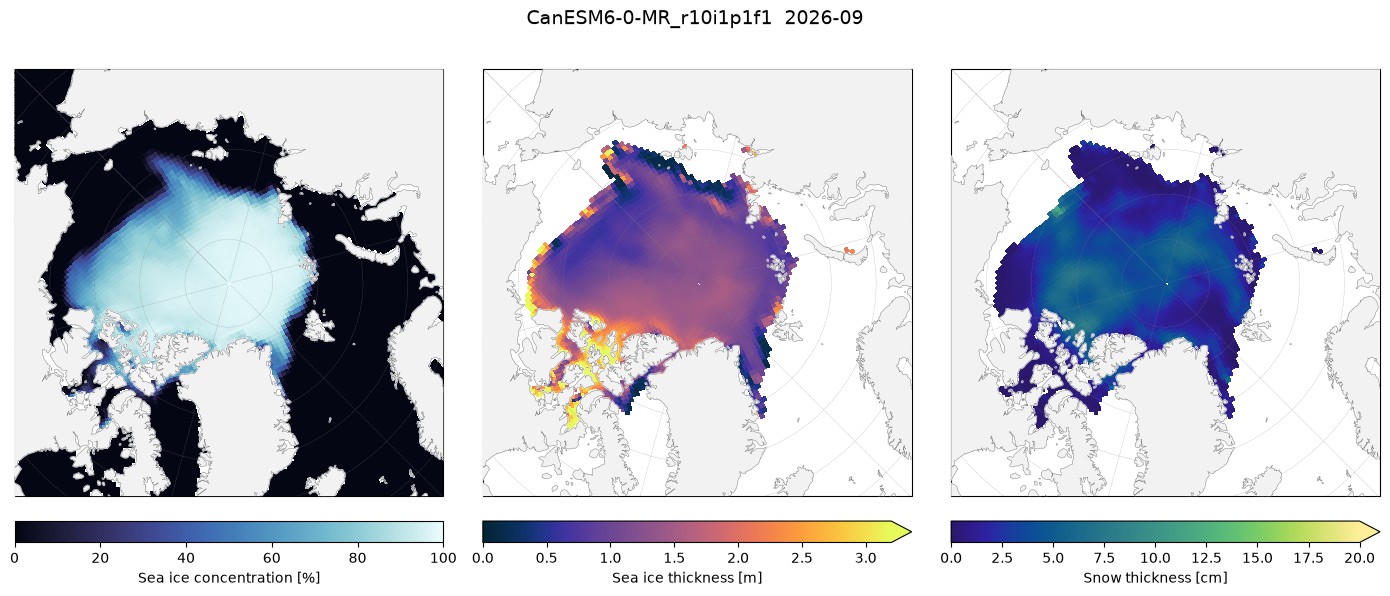

In [5]:
date = '2026-09'
member=0
fields = [CMIP7_siconc.sel(time=date).isel(member_id=member).siconc.isel(experiment_id=0).squeeze()
          , CMIP7_sithick.sel(time=date).isel(member_id=member).sithick.isel(experiment_id=0).squeeze()
          , CMIP7_snd.sel(time=date).isel(member_id=member).snd.isel(experiment_id=0).squeeze()*100]
labels = ['Sea ice concentration [%]', 'Sea ice thickness [m]', 'Snow thickness [cm]']
cmaps  = [cm.cm.ice, cm.cm.thermal, cm.cm.haline]   # swap snow cmap to taste
vlims  = [(0, 100), (0, 3.2), (0, 20)]              # adjust to your model range

proj = ccrs.LambertAzimuthalEqualArea(-45, 90)

fig, axs = plt.subplots(1, 3, figsize=(14, 6),
                        subplot_kw={'projection': proj})

for ax, da, lab, cmap, (vmin, vmax) in zip(axs, fields, labels, cmaps, vlims):
    p = ax.pcolormesh(da.lon, da.lat, da,
                      vmin=vmin, vmax=vmax, cmap=cmap,
                      transform=ccrs.PlateCarree(),
                      shading='auto', rasterized=True)

    ax.coastlines(resolution='50m', linewidth=0.15, color='black', zorder=10)
    ax.add_feature(cfeature.LAND, color='0.95', zorder=5)
    ax.gridlines(draw_labels=False, linewidth=0.25, color='gray',
                 alpha=0.7, linestyle='--', zorder=6)
    ax.set_extent([-180, 180, 66, 90], crs=ccrs.PlateCarree())

    fig.colorbar(p, ax=ax, orientation='horizontal',
                 pad=0.05, fraction=0.05, label=lab,
                 extend='max' if lab != 'Sea ice concentration [%]' else 'neither')

fig.suptitle(f'{str(fields[0].member_id.to_numpy())}  {date}', fontsize=14)
fig.tight_layout()

## Load CMIP6 and OSI SAF sea ice concentration from the cloud

From the public, anonymous-access S3 bucket `cmip6-regridded-us-west-2`:
- `CMIP6_sia`: precomputed CMIP6 `ssp245` sea ice area, 2015–2100, for every model and member (`sia_NH` in 10⁶ km²);
- `OSISAF_EN`: OSI SAF sea ice concentration on the EASE2 25 km Northern Hemisphere grid, November 2018 to April 2025.

In [6]:
bucket = 'cmip6-regridded-us-west-2'
experiment = 'SSP245'
s3 = s3fs.S3FileSystem(anon=True)

In [7]:
#CMIP6 sea ice concentration (SSP245)
CMIP6_sia = xr.open_zarr(s3fs.S3Map(root=f's3://{bucket}/{experiment}/time-series/CMIP6_sia_2015-2100.zarr', s3=s3, check=False)).compute().astype('float64')
#OSI SAF sea ice concentration (observations)
OSISAF_EN = xr.open_zarr(s3fs.S3Map(root=f's3://{bucket}/obs/EASE2-N25km/OSISAF_2018-11-2025-04.zarr', s3=s3, check=False)).compute()

While regridded and time-series CMIP6 data can be found on this S3 bucket, some data may need to be loaded via `CMIP6`, which searches and loads from both the Pangeo cloud and ESGF catalogs.

In [17]:
help(CMIP6)

Help on class CMIP6 in module scripts.data_access.load_cmip:

class CMIP6(builtins.object)
 |  CMIP6(
 |      variable,
 |      experiment_id,
 |      compare_exp=None,
 |      source_id='all',
 |      sector_mean=None,
 |      sector_sum=None,
 |      members=None,
 |      time_chunks=None,
 |      grid_label=['gn'],
 |      new_grid=None,
 |      method='conservative_normed',
 |      client=False,
 |      sic_mask=None,
 |      verbose=False,
 |      skip_sids=None,
 |      table_id=None,
 |      end_year=None,
 |      esgf_url='https://esgf-node.ornl.gov/esg-search',
 |      cat_url='https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.json',
 |      cat_url2='https://storage.googleapis.com/cmip6/cmip6-pgf-ingestion-test/catalog/catalog.json'
 |  )
 |
 |  Load CMIP6 sea ice output from the Pangeo cloud catalogs (preferred) and ESGF.
 |
 |  variable is a CMIP6 variable_id, a shorthand (sic, sit, snt; sia and sivolume need sector_sum),
 |  or a derived variable registered on dvr (sifb_d, s

## September sea ice area comparison

Sea ice area (10⁶ km²) for each dataset:
- **CMIP7 (CanESM6-0-MR)**: Σ(`siconc` × `areacello`) over the Northern Hemisphere. Times are first moved to the start of each month to match with the CMIP6 data.
- **CMIP6**: only members with data for all of 2015–2099 are kept (CAMS-CSM1-0 has no 2100). The CanESM5 models are also kept separately for comparison with CanESM6.
- **OSI SAF**: Σ concentration (%) × 625 km$^2$ cells.

In [9]:
#CanESM6_0_MR sea ice area (CMIP7)
CMIP7_siconc = preprocess_snap_to_month_start(CMIP7_siconc)
with ProgressBar():
    CanESM6_0_MR_sia_NH = ((CMIP7_siconc.siconc*CMIP7_siconc.areacello).where(lambda x:x.lat>0).sum(['x','y'])*10**-14).compute()

[########################################] | 100% Completed | 36.11 s


In [10]:
#CMIP6 sea ice area including all CanESM5 models
#only keep members that have data for the entire period
#CAMS-CSM1-0 has no data for 2100, so this period is defined as 2015 to 2099
CMIP6_sia_NH = CMIP6_sia.sia_NH.sel(member_id = CMIP6_sia.sia_NH.sel(time=slice('2015','2099')).dropna('member_id').member_id)
CanESM5_sia_NH = sel_model(CMIP6_sia.sia_NH,'CanESM5')
CanESM5_1_sia_NH = sel_model(CMIP6_sia.sia_NH,'CanESM5-1')
CanESM5_CanOE_sia_NH = sel_model(CMIP6_sia.sia_NH,'CanESM5-CanOE')

In [11]:
#observed sea ice area
OSISAF_sia_NH = (OSISAF_EN.sic.sum(['x', 'y'])*6.25/1e6)

The figure shows September (minimum) sea ice area:
- black: CMIP6 multi-model mean ± 1σ (spread across models' ensemble means);
- blue: CanESM5 models;
- red: CanESM6-0-MR (thin lines: members; thick line: mean);
- green: OSI SAF.

The dashed line at 1 million km$^2$ is the usual "ice-free" threshold.

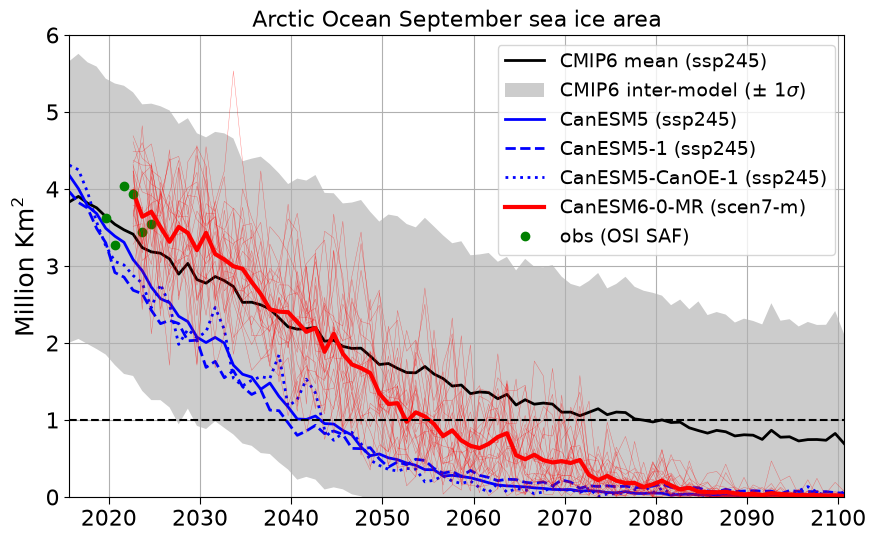

In [12]:
fig = plt.figure(figsize=(10, 6))
gs = plt.GridSpec(1,1,
                       width_ratios=[1],
                       height_ratios=[1]
                       )

sigma=1
CMIP6_sia_NH_sep = CMIP6_sia_NH.where(lambda x:x.time.dt.month==9,drop=True)
CanESM5_sia_NH_sep = CanESM5_sia_NH.where(lambda x:x.time.dt.month==9,drop=True)
CanESM5_1_sia_NH_sep = CanESM5_1_sia_NH.where(lambda x:x.time.dt.month==9,drop=True)
CanESM5_CanOE_NH_sia_NH_sep = CanESM5_CanOE_sia_NH.where(lambda x:x.time.dt.month==9,drop=True)
CanESM6_0_MR_sia_NH_sep = CanESM6_0_MR_sia_NH.where(lambda x:x.time.dt.month==9,drop=True)
OSISAF_sia_NH_sep = OSISAF_sia_NH.where(lambda x:x.time.dt.month==9,drop=True)

ax = fig.add_subplot(gs[0])

ensemble_mean(CMIP6_sia_NH_sep).mean('member_id').plot(color='k',lw=2,label='CMIP6 mean (ssp245)',alpha=1,ax=ax)
lower_bound_std = ensemble_mean(CMIP6_sia_NH_sep).mean('member_id') - ensemble_mean(CMIP6_sia_NH_sep).std('member_id')*sigma
upper_bound_std = ensemble_mean(CMIP6_sia_NH_sep).mean('member_id') + ensemble_mean(CMIP6_sia_NH_sep).std('member_id')*sigma
ax.fill_between(ensemble_mean(CMIP6_sia_NH_sep).time,lower_bound_std,upper_bound_std,facecolor='k',alpha=.2,lw=0,label=r'CMIP6 inter-model ($\pm$ 1$\sigma$)')
CanESM5_sia_NH_sep.mean('member_id').plot(color='blue',lw=2,alpha=1,ax=ax,label = 'CanESM5 (ssp245)')
CanESM5_1_sia_NH_sep.mean('member_id').plot(color='blue',lw=2,alpha=1,ls='--',ax=ax,label = 'CanESM5-1 (ssp245)')
CanESM5_CanOE_NH_sia_NH_sep.mean('member_id').plot(color='blue',lw=2,alpha=1,ls=':',ax=ax,label = 'CanESM5-CanOE-1 (ssp245)')
CanESM6_0_MR_sia_NH_sep.mean('member_id').plot(color='red',lw=3,alpha=1,ls='-',ax=ax,label = 'CanESM6-0-MR (scen7-m)')
OSISAF_sia_NH_sep.where(lambda x:x.time.dt.month==9,drop=True).sel(time=slice('2015','2026')).plot(c='green',marker='o',ls='', label='obs (OSI SAF)')
[CanESM6_0_MR_sia_NH_sep.sel(member_id=x).plot(color='red',lw=.3,alpha=.5,ax=ax) for _,x in enumerate(CanESM6_0_MR_sia_NH_sep.member_id)]

ax.set_ylim(0,6)
#ax.set_yticks(np.arange(1,2.1,.2))
ax.grid()
ax.set_xlim(CMIP6_sia_NH_sep.time[0],CMIP6_sia_NH_sep.time[-1])
ax.legend(fontsize=14,loc='upper right')
#ax.set_xticks(np.arange(2022,2100,5))
#ax.set_xticks(np.arange(2022,2100,1),minor=True)
#ax.set_yticks(np.arange(7,11,.5),minor=True)
plt.tick_params(axis='x', length=3,which='minor')
plt.tick_params(axis='x', length=5,which='major')
#ax.set_xticklabels('')
ax.tick_params(labelsize=16)
ax.set_title('Arctic Ocean September sea ice area',fontsize=16)
ax.set_ylabel('',fontsize=16)
ax.set_xlabel('')
ax.axhline(1,ls='--',color='k')
ax.set_ylabel('Million Km$^{2}$',fontsize=18)
plt.savefig(REPO_ROOT / 'results' / 'figures' / 'CMIP7_CMIP6_sia_sep.png', dpi=300, bbox_inches='tight')

## Clean up

Raw ESGF downloads are kept in `/tmp/esgf_manual`, where space is limited. Set `clear_cache=True` to delete them once you have saved what you need. Datasets loaded before clearing still point at the deleted files, so re-run their load cells before using them again.

In [13]:
clear_cache=False

In [14]:
# Free /tmp space used by the raw ESGF downloads
if clear_cache==True:
    clear_esgf_cache()